# Preparación de datos — leads_3000\n
\n
Este notebook prepara el dataset `leads_3000.csv` para tareas de modelado. Incluye:\n
\n
- Carga y validación básica (dimensiones, tipos, faltantes).\n
- Limpieza ligera de columnas tipo texto/categóricas sin contaminar nulos.\n
- Transformación de `lead_clase` (texto) a etiqueta numérica `lead_clase_id` (0, 1, 2).\n
- Revisión de balance de clases y recomendación práctica.\n
- Partición train/test estratificada y export de artefactos a `algoritmos/outputs/`.

In [10]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

try:
    from sklearn.model_selection import train_test_split
except ImportError as e:
    raise ImportError("Falta scikit-learn. Instala con: pip install scikit-learn") from e

sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
DATA_PATH = ROOT / 'leads_3000.csv'
OUT_DIR = ROOT / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH, OUT_DIR

(WindowsPath('c:/Users/MARIANA/Desktop/LAIDA/algoritmos/leads_3000.csv'),
 WindowsPath('c:/Users/MARIANA/Desktop/LAIDA/algoritmos/outputs'))

In [2]:
df = pd.read_csv(DATA_PATH)
print('shape:', df.shape)
df.head(3)

shape: (3000, 6)


,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase
0,L00001,CHUCK_04,"Excelente decision, te ayudo a completar tu co...",compra,0,tibio
1,L00002,CHUCK_01,"Claro, te comparto el precio actualizado del p...",consulta_precio,1,caliente
2,L00003,CHUCK_01,Retomo la conversacion para ayudarte con la de...,seguimiento,0,tibio


In [3]:
display(df.dtypes)
display(df.isna().mean().sort_values(ascending=False))
display(df.duplicated().sum())

lead_id            str
chuck_id           str
mensaje_chuck      str
intencion          str
pre_precio       int64
lead_clase         str
dtype: object

lead_id          0.0
chuck_id         0.0
mensaje_chuck    0.0
intencion        0.0
pre_precio       0.0
lead_clase       0.0
dtype: float64

np.int64(0)

## Limpieza ligera (sin convertir nulos a "nan")\n
\n
- Se normalizan espacios y mayúsculas/minúsculas solo en columnas categóricas.\n
- Para texto libre (`mensaje_chuck`) se hace `strip()` y se conserva el contenido.\n
- Se preservan faltantes como `pd.NA`.

In [4]:
def safe_strip(series: pd.Series) -> pd.Series:
    s = series.astype('string')
    return s.where(s.isna(), s.str.strip())

# Columnas esperadas
expected_cols = ['lead_id', 'chuck_id', 'mensaje_chuck', 'intencion', 'pre_precio', 'lead_clase']
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    raise ValueError(f'Faltan columnas esperadas: {missing}')

df = df.copy()

# Normalización mínima
df['lead_id'] = safe_strip(df['lead_id'])
df['chuck_id'] = safe_strip(df['chuck_id']).str.upper()
df['mensaje_chuck'] = safe_strip(df['mensaje_chuck'])
df['intencion'] = safe_strip(df['intencion']).str.lower()
df['lead_clase'] = safe_strip(df['lead_clase']).str.lower()

# Asegurar pre_precio como entero 0/1
df['pre_precio'] = pd.to_numeric(df['pre_precio'], errors='coerce').astype('Int64')

df.head(3)

,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase
0,L00001,CHUCK_04,"Excelente decision, te ayudo a completar tu co...",compra,0,tibio
1,L00002,CHUCK_01,"Claro, te comparto el precio actualizado del p...",consulta_precio,1,caliente
2,L00003,CHUCK_01,Retomo la conversacion para ayudarte con la de...,seguimiento,0,tibio


## Transformación de `lead_clase` a 0/1/2\n
\n
Se crea `lead_clase_id` con el siguiente mapeo (ordenado por nivel de prioridad):\n
\n
- `frio` → 0\n
- `tibio` → 1\n
- `caliente` → 2

In [5]:
LEAD_CLASE_TO_ID = {
    'frio': 0,
    'tibio': 1,
    'caliente': 2,
}
ID_TO_LEAD_CLASE = {v: k for k, v in LEAD_CLASE_TO_ID.items()}

df['lead_clase_id'] = df['lead_clase'].map(LEAD_CLASE_TO_ID).astype('Int64')

unmapped = df.loc[df['lead_clase'].notna() & df['lead_clase_id'].isna(), 'lead_clase'].unique().tolist()
if unmapped:
    raise ValueError(f'Valores de lead_clase sin mapear: {unmapped}')

df[['lead_clase', 'lead_clase_id']].drop_duplicates().sort_values('lead_clase_id')

,lead_clase,lead_clase_id
3,frio,0
0,tibio,1
1,caliente,2


## ¿La cantidad de registros por clase debe ser igual?\n
\n
No necesariamente. En problemas reales es común tener desbalance (por ejemplo, más leads *tibios* que *calientes*).\n
\n
Lo importante es manejarlo correctamente:\n
\n
- Mantener proporciones similares en train/test (split estratificado).\n
- Evaluar con métricas adecuadas (F1 por clase, matriz de confusión).\n
- Si el desbalance afecta el desempeño, considerar *class weights* o re-muestreo **solo en entrenamiento** (oversampling/undersampling).\n
\n
A continuación se muestra la distribución actual.

In [6]:
counts = df['lead_clase'].value_counts(dropna=False)
pct = (df['lead_clase'].value_counts(normalize=True, dropna=False) * 100).round(2)
pd.DataFrame({'n': counts, '%': pct})

,n,%
lead_clase,,
tibio,1368,45.6
frio,879,29.3
caliente,753,25.1


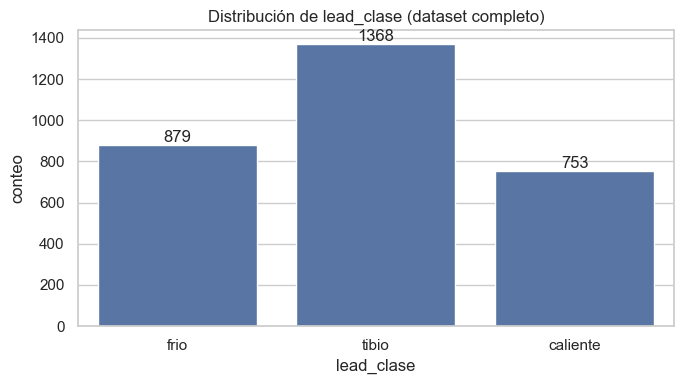

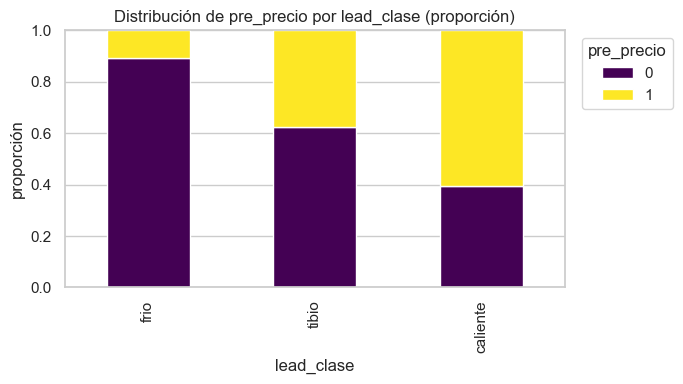

WindowsPath('c:/Users/MARIANA/Desktop/LAIDA/algoritmos/outputs/prep_stack_pre_precio_by_lead_clase.png')

In [11]:
# Gráficas de distribución (dataset completo)
plot_dir = OUT_DIR
plot_dir.mkdir(parents=True, exist_ok=True)

# 1) Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(7, 4))
order = ['frio', 'tibio', 'caliente']
sns.countplot(data=df, x='lead_clase', order=order, ax=ax)
ax.set_title('Distribución de lead_clase (dataset completo)')
ax.set_xlabel('lead_clase')
ax.set_ylabel('conteo')
for container in ax.containers:
    ax.bar_label(container)
fig.tight_layout()
fig_path = plot_dir / 'prep_count_lead_clase.png'
fig.savefig(fig_path, dpi=160)
plt.show()
fig_path

# 2) pre_precio vs lead_clase (proporción dentro de cada clase)
ct = pd.crosstab(df['lead_clase'], df['pre_precio'], normalize='index')
ct = ct.reindex(order)
fig, ax = plt.subplots(figsize=(7, 4))
ct.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')
ax.set_title('Distribución de pre_precio por lead_clase (proporción)')
ax.set_xlabel('lead_clase')
ax.set_ylabel('proporción')
ax.legend(title='pre_precio', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
fig.tight_layout()
fig_path = plot_dir / 'prep_stack_pre_precio_by_lead_clase.png'
fig.savefig(fig_path, dpi=160)
plt.show()
fig_path

## Split train/test estratificado\n
\n
Se divide el dataset preservando la distribución de `lead_clase_id`.

In [7]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['lead_clase_id'],
)

print('train:', train_df.shape, 'test:', test_df.shape)
display(train_df['lead_clase'].value_counts(normalize=True).round(3))
display(test_df['lead_clase'].value_counts(normalize=True).round(3))

train: (2400, 7) test: (600, 7)


lead_clase
tibio       0.456
frio        0.293
caliente    0.251
Name: proportion, dtype: Float64

lead_clase
tibio       0.455
frio        0.293
caliente    0.252
Name: proportion, dtype: Float64

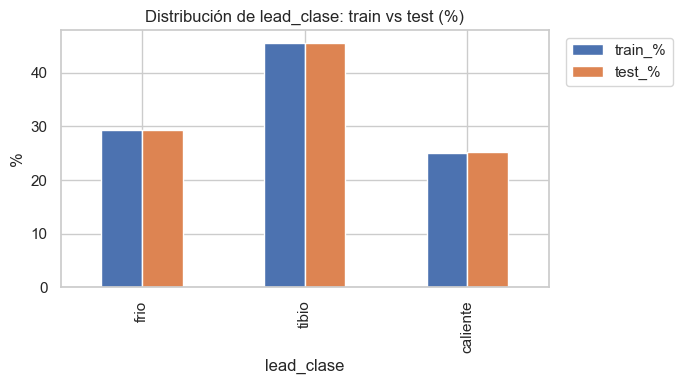

WindowsPath('c:/Users/MARIANA/Desktop/LAIDA/algoritmos/outputs/prep_dist_train_vs_test.png')

In [12]:
# Gráfica: comparación de distribución de clases (train vs test)
def class_distribution(frame: pd.DataFrame, name: str) -> pd.DataFrame:
    out = frame['lead_clase'].value_counts(normalize=True).mul(100).rename(name).to_frame()
    return out.reindex(['frio', 'tibio', 'caliente'])

dist = pd.concat([
    class_distribution(train_df, 'train_%'),
    class_distribution(test_df, 'test_%'),
], axis=1)

fig, ax = plt.subplots(figsize=(7, 4))
dist.plot(kind='bar', ax=ax)
ax.set_title('Distribución de lead_clase: train vs test (%)')
ax.set_xlabel('lead_clase')
ax.set_ylabel('%')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig_path = OUT_DIR / 'prep_dist_train_vs_test.png'
fig.savefig(fig_path, dpi=160)
plt.show()
fig_path

## Export de artefactos\n
\n
Se exporta un CSV preparado completo y los splits train/test.

In [8]:
prepared_path = OUT_DIR / 'leads_3000_prepared.csv'
train_path = OUT_DIR / 'leads_3000_train.csv'
test_path = OUT_DIR / 'leads_3000_test.csv'

df.to_csv(prepared_path, index=False)
train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

prepared_path, train_path, test_path

(WindowsPath('c:/Users/MARIANA/Desktop/LAIDA/algoritmos/outputs/leads_3000_prepared.csv'),
 WindowsPath('c:/Users/MARIANA/Desktop/LAIDA/algoritmos/outputs/leads_3000_train.csv'),
 WindowsPath('c:/Users/MARIANA/Desktop/LAIDA/algoritmos/outputs/leads_3000_test.csv'))